In [1]:
from preamble import *

2025-05-26 17:17:28,917 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch


In [2]:
def dWS13_transmission_model(R_0 = (3.6 * u.R_earth).cgs.value,  # [cm]
                             T_ref = (600 * u.K).value,
                             P_ref = 0.1,
                             power = 0.05,
                             Mp = (15 * u.M_earth).cgs.value,  # [g]
                             R_star = (0.8 * u.R_sun).cgs.value,  # [cm]
                             plot=False ):
       
    g = (c.G * Mp / R_0**2).cgs.value  # [cm/s2]
    T = T_ref * (pressures / P_ref) ** power  # [K]
    
    chem = FastchemWrapper(T, pressures)
    vmr = chem.vmr()
    weights_amu = chem.get_weights()
    vmr_indices = chem.get_column_index(species_name=molecules)
    
    molecular_opacities = []
    for i, mol in enumerate(molecules):
        this_mol_op = binned_opacities[i](T, pressures)
        molecular_opacities.append(this_mol_op)
    
    total_opacity = jnp.array(molecular_opacities).sum(axis=0)
    
    Rp_Rs = de_wit_seager_2013.transmission_radius(
        wavelengths, T, pressures,
        g, R_0,
        total_opacity[None, ...],
        vmr, vmr_indices, weights_amu,
        rayleigh_scattering=True) / R_star

    if plot:
        # plot transmission spectrum:
        ax = plt.gca()
        ax.plot(wavelengths, Rp_Rs)
        
        ax.set(
            xlabel='Wavelength [µm]',
            ylabel='$R_{\\rm p}~/~R_{\\rm s}$',
            # ylim=(0.009, 0.014)
        )

        fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
        
        ax[0].semilogy(T, pressures, color='k')
        ax[0].set(
            xlabel='Temperature [K]',
            ylabel='Pressure [bar]',
            title='p-T structure'
        )
        ax[0].invert_yaxis()
        
        for molecule, vmr_i in zip(molecules, vmr[:, vmr_indices].T):
            ax[1].loglog(vmr_i, pressures, label=molecule.replace('2', '$_2$'))
        ax[1].legend()
        ax[1].set(
            xlabel='VMR',
            title='Chemistry'
        )
        plt.savefig(f'../figs/{visit}_pt-profile.png')
    
    return Rp_Rs

In [3]:
def plot_broadband_lc(params, rp = 0.044, systematics = 1.0, bphase = 0, plot=False, savefigs=False, samples=None):

    'Specify and bin the spectra for these temperatures'
    kwargs = dict(
    bin_specification = 'edges',
    bins=broadband_bin_edges,
    min=broadband_bin_edges.min(),
    max=broadband_bin_edges.max(), log=False)
    Cool, Phot = [
        bin_spectrum(
            get_BTSettl_spectrum(T=Temp), **kwargs
        )
        for Temp in [params.get('T_spot', default_params['T_spot']), params.get('T_phot', default_params['T_phot'])] ]

    'Update Planet Parameters'
    planet_parameters['u1'] = params.get('u1', default_params['u1'])
    planet_parameters['u2'] = params.get('u2', default_params['u2'])
    planet_parameters['rp'] = rp
    
    'Update stellar parameters'
    active_star.phot = Phot.flux.value
    active_star.wavelength = Phot.wavelength.to_value(u.m)
    active_star.spectrum = jnp.array([Cool.flux.value] * (n_spots+n_fixedspots))

    'Calculate fleck model'
    lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)
    if visit == 'F21':
        lc_index=2
    if visit == 'S22':
        lc_index=0
    fleck_lc = lc.T[lc_index]
    fleck_lc /= np.nanmean(fleck_lc)

    'Normalize the model and data'
    model = systematics * fleck_lc
    normalized_model = model / np.nanmean(model)
    normalized_flux = broadband_data_flux / np.nanmean(broadband_data_flux)
    'Calculate ln_like for the light curve model'
    lc_chisq = np.nansum(((normalized_flux - normalized_model) ** 2) / (broadband_relative_err ** 2))

    'Set up the data + model plots'
    fig, axes = plt.subplots(4, 1, figsize=(5, 6))
    plt.title(f"{visit} Broadband Flux Model")
    axes[0].set_xlabel("Time from midtransit")
    axes[0].set_ylabel("Relative Flux")
    axes[1].set_title("Systematic-corrected")
    axes[1].set_xlabel("Time from midtransit")
    axes[2].set_title("Residuals")
    axes[2].set_xlabel("Time from midtransit")
    axes[2].set_ylabel(r"$\sigma$")
    axes[3].set_title("Residuals")
    axes[3].set_xlabel("HST Phase")
    axes[3].set_ylabel(r"$\sigma$")

    # First plot (data + model)
    axes[0].errorbar(
        time_from_T0,
        normalized_flux,
        yerr=broadband_relative_err,fmt='o',ms=2,color='royalblue')
    # Second plot (data & model)/systematics
    axes[1].errorbar(
        time_from_T0,
        (normalized_flux/systematics)/np.nanmean(normalized_flux/systematics),
        yerr=broadband_relative_err,fmt='o',ms=2,color='royalblue')
    # third plot residuals
    axes[2].scatter(
        time_from_T0,
        (normalized_flux-normalized_model)/broadband_relative_err,s=2,color='royalblue')
    # fourth plot residuals in HST phase
    axes[3].scatter(
        bphase,
        (normalized_flux-normalized_model)/broadband_relative_err,s=2,color='royalblue')

    # Plot the models
    axes[0].plot(
        time_from_T0,
        normalized_model,
        color='k',zorder=100)
    axes[1].plot(
        time_from_T0,
        fleck_lc,
        color='k',zorder=100)
    if savefigs:
        plt.savefig(f'../figs/{visit}_{n_spots}spots_{nsteps}steps_broadbandLC.png',dpi=250)
    plt.show()
    plt.clf()

    'Same Plot but Zoomed In'
    fig, axes = plt.subplots(4, 1, figsize=(5, 6))
    plt.title(f"{visit} Broadband Flux Model (Transit Only)")
    axes[0].set_title(f"{visit}")
    axes[0].set_xlabel("Time from midtransit")
    axes[0].set_ylabel("Relative Flux")
    axes[0].set_xlim(-0.09,0.09)
    axes[1].set_title("Systematic-corrected")
    axes[1].set_xlabel("Time from midtransit")
    axes[1].set_xlim(-0.09,0.09)
    axes[2].set_title("Residuals")
    axes[2].set_xlabel("Time from midtransit")
    axes[2].set_ylabel(r"$\sigma$")
    axes[2].set_xlim(-0.09,0.09)
    axes[3].set_title("Residuals")
    axes[3].set_xlabel("HST Phase")
    axes[3].set_ylabel(r"$\sigma$")
    axes[0].set_xlim(-0.086,0.086)
    axes[1].set_xlim(-0.086,0.086)
    axes[2].set_xlim(-0.086,0.086)
    axes[3].set_xlim(np.nanmin(bphase),np.nanmax(bphase))
    axes[0].set_ylim(np.nanmin(normalized_flux[( (orbit == 3) | (orbit == 4) | (orbit == 5) )])-3*np.nanmean(relative_err),3*np.nanmean(relative_err)+np.nanmax(normalized_flux[( (orbit == 3) | (orbit == 4) | (orbit == 5) )]))
    axes[0].set_ylim(np.nanmin(normalized_flux[( (orbit == 3) | (orbit == 4) | (orbit == 5) )])-3*np.nanmean(relative_err),3*np.nanmean(relative_err)+np.nanmax(normalized_flux[( (orbit == 3) | (orbit == 4) | (orbit == 5) )]))
    
    # First plot (data + model)
    axes[0].errorbar(
        time_from_T0,
        normalized_flux,
        yerr=broadband_relative_err,fmt='o',ms=2,color='royalblue')
    # Second plot (data & model)/systematics
    axes[1].errorbar(
        time_from_T0,
        (normalized_flux/systematics)/np.nanmean(normalized_flux/systematics),
        yerr=broadband_relative_err,fmt='o',ms=2,color='royalblue')
    # third plot residuals
    axes[2].scatter(
        time_from_T0,
        (normalized_flux-normalized_model)/broadband_relative_err,s=2,color='royalblue')
    # fourth plot residuals in HST phase
    axes[3].scatter(
        bphase,
        (normalized_flux-normalized_model)/broadband_relative_err,s=2,color='royalblue')

    # Plot the models
    axes[0].plot(
        time_from_T0,
        normalized_model,
        color='k',zorder=100)
    axes[1].plot(
        time_from_T0,
        fleck_lc,
        color='k',zorder=100)
    if savefigs:
        plt.savefig(f'../figs/{visit}_{n_spots}spots_{nsteps}steps_broadbandLC_zoomedin.png',dpi=250)
    plt.show()
    plt.clf()

    dof = np.sum(~np.isnan(time_from_T0)) - (ndim-2*len(wavelengths))
    reduced_chisq = lc_chisq/dof
    
    print(f'This Models Reduced Chisq = {reduced_chisq:.3f} for {ndim-2*len(wavelengths)} parameters and {np.sum(~np.isnan(time_from_T0))} data points')

In [4]:
def plot_spec_lc(params, rp = 0.044, systematics = 1, bphase = 0, savefigs=False, samples=None):

    'Set binning preferences and download model spectra'
    kwargs = dict(
    bin_specification = 'edges',
    bins=spec_bin_edges,
    min=spec_bin_edges.min(),
    max=spec_bin_edges.max(), log=False)
    Cool, Phot = [
        bin_spectrum(
            get_BTSettl_spectrum(T=Temp), **kwargs
        )
        for Temp in [params.get('T_spot', default_params['T_spot']), params.get('T_phot', default_params['T_phot'])] ]

    'Update Planet Parameters'
    planet_parameters['u1'] = np.array([params[f"u1_w{j}"] for j in range(1,len(spec_bin_edges))])
    planet_parameters['u2'] = np.array([params[f"u2_w{j}"] for j in range(1,len(spec_bin_edges))])
    planet_parameters['rp'] = rp

    'Update stellar parameters'
    active_star.phot = Phot.flux.value
    active_star.wavelength = Phot.wavelength.to_value(u.m)
    active_star.spectrum = jnp.array([Cool.flux.value] * (n_spots+n_fixedspots))

    lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)        
        
    'Plot the transmission and contamination spectra'
    'First Remove nan data'
    mask = ~np.isnan(time_from_T0)
    nonnan_time_from_T0 = time_from_T0[mask]
    active_star.times = nonnan_time_from_T0
    _, nanremoved_contam, _, _, nanremoved_spectrum_at_transit = active_star.transit_model(**planet_parameters)
    fig, axs = plt.subplots(3,1,figsize=(5,5))
    axs[0].set_title('Contaminated Transmission Spectrum')
    axs[0].scatter(wavelengths, nanremoved_contam * 1e6 ,s=2,color='k')
    axs[1].set_title('Stellar Contamination')
    axs[1].scatter(wavelengths, (nanremoved_contam-planet_parameters['rp']**2)*1e6,s=2,color='k')
    axs[2].set_title('De-contaminated Transmission Spectrum')
    axs[2].scatter(wavelengths, (planet_parameters['rp'])**2 * 1e6,s=2,color='k')
    axs[0].set_ylabel('Transit Depth (ppm)')
    axs[1].set_ylabel('Transit Depth (ppm)')
    axs[2].set_ylabel('Transit Depth (ppm)')
    plt.xlabel(r'Wavelength ($\mu$m)')
    if savefigs:
        plt.savefig(f'../figs/{visit}_{n_spots}spots_{nsteps}steps_{len(spec_bin_edges)-1}bins_transmission.png',dpi=250)
    plt.show()
    plt.clf()

    'Re-set to the original array (containing nans)'
    active_star.times = time_from_T0
    
    'Set up the data + model plots'
    fig, axes = plt.subplots(4, 1, figsize=(5,12))
    axes[0].set_title(f"{visit}")
    axes[0].set_xlabel("Time from midtransit")
    axes[0].set_ylabel("Relative Flux")
    axes[1].set_title("Systematic-corrected")
    axes[1].set_xlabel("Time from midtransit")
    axes[2].set_title("Residuals")
    axes[2].set_xlabel("Time from midtransit")
    axes[2].set_ylabel(r"$\sigma$")
    axes[3].set_title("Residuals")
    axes[3].set_xlabel("HST Phase")
    axes[3].set_ylabel(r"$\sigma$")
    
    chisq_per_wavelength = []
    for i, lc_i in enumerate(lc.T):
        lc_i /= np.nanmean(lc_i)
        model_i = systematics * lc_i
        model_i /= np.nanmedian(model_i)
        normalized_flux = data_flux[i, :]/np.nanmedian(data_flux[i, :])
        chisq = np.nansum(((normalized_flux - model_i) ** 2) / (relative_err[i, :] ** 2))
        chisq_per_wavelength.append(chisq)
    
        # First plot (data + model)
        axes[0].errorbar(
            time_from_T0,
            normalized_flux - (0.003*i),
            yerr=relative_err[i, :],fmt='o',ms=1,
            color=plt.cm.turbo((wavelengths[i] - wavelengths.min()) / np.ptp(wavelengths)))
        # Second plot (data & model)/systematics
        axes[1].errorbar(
            time_from_T0,
            (normalized_flux/systematics)/np.nanmean(normalized_flux/systematics) - (0.003*i),
            yerr=relative_err[i, :],fmt='o',ms=1,
            color=plt.cm.turbo((wavelengths[i] - wavelengths.min()) / np.ptp(wavelengths)))
        # third plot residuals
        axes[2].scatter(
            time_from_T0,
            (normalized_flux-model_i)/relative_err[i, :],s=2,
            color=plt.cm.turbo((wavelengths[i] - wavelengths.min()) / np.ptp(wavelengths)))
        # fourth plot residuals in HST phase
        axes[3].scatter(
            bphase,
            (normalized_flux-model_i)/relative_err[i, :],s=2,
            color=plt.cm.turbo((wavelengths[i] - wavelengths.min()) / np.ptp(wavelengths)))

        # Plot the models
        axes[0].plot(
            time_from_T0,
            model_i - (0.003*i),
            color='k',zorder=100)
        axes[1].plot(
            time_from_T0,
            lc_i - (0.003*i),
            color='k',zorder=100)
    if savefigs:
        plt.savefig(f'../figs/{visit}_{n_spots}spots_{nsteps}steps_{len(spec_bin_edges)-1}bins_specLC.png',dpi=250)
    plt.show()
    plt.clf()

    'Set up the data + model plots'
    fig, axes = plt.subplots(4, 1, figsize=(4, 10))
    axes[0].set_title(f"{visit}")
    axes[0].set_xlabel("Time from midtransit")
    axes[0].set_ylabel("Relative Flux")
    # axes[0].set_xlim(-0.085,0.085)
    axes[1].set_title("Systematic-corrected")
    axes[1].set_xlabel("Time from midtransit")
    # axes[1].set_xlim(-0.085,0.085)
    axes[2].set_title("Residuals")
    axes[2].set_xlabel("Time from midtransit")
    axes[2].set_ylabel(r"$\sigma$")
    # axes[2].set_xlim(-0.085,0.085)
    axes[3].set_title("Residuals")
    axes[3].set_xlabel("HST Phase")
    axes[3].set_ylabel(r"$\sigma$")
    axes[0].set_xlim(-0.086,0.086)
    axes[1].set_xlim(-0.086,0.086)
    axes[2].set_xlim(-0.086,0.086)
    axes[3].set_xlim(np.nanmin(bphase),np.nanmax(bphase))
    residual_flux = []
    for i, lc_i in enumerate(lc.T):
        lc_i /= np.nanmean(lc_i)
        model_i = systematics * lc_i
        model_i /= np.nanmean(model_i)

        normalized_flux = data_flux[i, :]/np.nanmean(data_flux[i, :])

        residual_flux.append( (normalized_flux-model_i)/relative_err[i, :] )
    
        # First plot (data + model)
        axes[0].errorbar(
            time_from_T0,
            normalized_flux - (0.003*i),
            yerr=relative_err[i, :],fmt='o',ms=1,
            color=plt.cm.turbo((wavelengths[i] - wavelengths.min()) / np.ptp(wavelengths)))
        # Second plot (data & model)/systematics
        axes[1].errorbar(
            time_from_T0,
            (normalized_flux/systematics)/np.nanmean(normalized_flux/systematics) - (0.003*i),
            yerr=relative_err[i, :],fmt='o',ms=1,
            color=plt.cm.turbo((wavelengths[i] - wavelengths.min()) / np.ptp(wavelengths)))
        # third plot residuals
        axes[2].scatter(
            time_from_T0,
            (normalized_flux-model_i)/relative_err[i, :],s=2,
            color=plt.cm.turbo((wavelengths[i] - wavelengths.min()) / np.ptp(wavelengths)))
        # fourth plot residuals in HST phase
        axes[3].scatter(
            bphase,
            (normalized_flux-model_i)/relative_err[i, :],s=2,
            color=plt.cm.turbo((wavelengths[i] - wavelengths.min()) / np.ptp(wavelengths)))

        # Plot the models
        axes[0].plot(
            time_from_T0,
            model_i - (0.003*i),
            color='k',zorder=100)
        axes[1].plot(
            time_from_T0,
            lc_i - (0.003*i),
            color='k',zorder=100)

    if savefigs:
        plt.savefig(f'../figs/{visit}_{n_spots}spots_{nsteps}steps_{len(spec_bin_edges)-1}bins_zoomedspeclcs.png',dpi=250)
    plt.show()
    plt.clf()

    residual_rainbow = Rainbow(time = time_from_T0*u.day, wavelength = wavelengths*u.micron, flux = np.array(residual_flux)*u.dimensionless_unscaled, uncertainty = relative_err*u.dimensionless_unscaled)
    residual_rainbow.save(f"../data/{visit}_model_residuals.rainbow.npy")
    
    total_chisq = np.nansum(chisq_per_wavelength)
    dof = np.sum(~np.isnan(time_from_T0))*len(wavelengths) - (ndim-2)
    reduced_chisq = total_chisq/dof
    print(f'This Models Reduced Chisq = {reduced_chisq:.3f} for {ndim-2} parameters and {np.sum(~np.isnan(time_from_T0))*len(wavelengths)} data points')

In [5]:
def plot_results(params, savefigs=False, transmission=False, samples=None):

    active_star.times = time_from_T0
    active_star.T_eff = params.get('T_phot',default_params['T_phot'])
    active_star.temperature = jnp.array([params.get("T_spot", default_params["T_spot"])] * (n_spots+n_fixedspots))
    active_star.rad = jnp.array([10**(params['log_fixedspot_radii'])] * (n_spots+n_fixedspots))
    active_star.lon = active_star.lon.at[-n_spots:].set([params.get(f"spot{i}_lon", default_params[f"spot{i}_lon"]) for i in range(1, n_spots + 1)][::-1])
    active_star.lat = active_star.lat.at[-n_spots:].set([params.get(f"spot{i}_lat", default_params[f"spot{i}_lat"]) for i in range(1, n_spots + 1)][::-1])
    active_star.rad = active_star.rad.at[-n_spots:].set([params.get(f"spot{i}_rad", default_params[f"spot{i}_rad"]) for i in range(1, n_spots + 1)][::-1])

    # rp_array = np.array([f'rp_rs_{i}' for i in range(1, len(wavelengths) + 1)])
    # if transmission:
    rp_array = dWS13_transmission_model(R_0 = (params.get('R_0',default_params['R_0']) * u.R_earth).cgs.value,  # [cm]
                                                       T_ref = (params.get('T_ref',default_params['T_ref']) * u.K).value, )
    planet_parameters['t0'] = params.get('T_0', default_params['T_0'])
    planet_parameters['a'] = params.get('a_rstar', default_params['a_rstar'])
    planet_parameters['ecc'] = params.get('ecc', default_params['ecc'])
    planet_parameters['inclination'] = np.radians(params.get('planet_i', default_params['planet_i']))
    'Calculate Systematics'
    ramp = ramp_model(phase = ramp_phase,
                      r1=params.get('r1', default_params['r1']),
                      r2=params.get('r2', default_params['r2']),
                      r3=params.get('r3', default_params['r3']),)
    bphase = ( (img_date-ref_time[0]+0.02)/(params.get('HST_period', default_params['HST_period'])) ) % 1
    breathing = breathing_model(phase = bphase,
                                b1=params.get('b1', default_params['b1']),
                                b2=params.get('b2', default_params['b2']),
                                b3=params.get('b3', default_params['b3']),
                                b4=params.get('b4', default_params['b4']),)
    # slope = params.get('slope', default_params['slope'])
    systematics = (breathing * ramp)
    
    'Plot the stellar surface'
    active_star.plot_star(
        t0=planet_parameters['t0'],
        rp=np.nanmean(planet_parameters['rp']),  # Exoplanet radius in units of stellar radii
        a=planet_parameters['a'],  # Planetary semi-major axis in units of stellar radii
        inclination=planet_parameters['inclination'],  # Planetary orbital inclination [radians]
        ecc=planet_parameters['ecc'] )
    plt.title(f'{visit} Stellar Background at T0')
    if savefigs:
        plt.savefig(f'../figs/{visit}_{n_spots}spots_{nsteps}steps_starmap.png', dpi=250)
    plt.show()
    plt.clf()
    
    'Plot the systematics models'
    fig, axs = plt.subplots(4,1, figsize=(6,6))
    plt.title('Systematics')
    axs[0].set_title('Ramp')
    axs[1].set_title('Breathing')
    axs[2].set_title('Breathing')
    axs[3].set_title('Ramp x Breathing')
    axs[0].scatter(ramp_phase, ramp,color='k',alpha=0.8,s=2)
    axs[1].scatter(bphase, breathing,color='k',alpha=0.8,s=2)
    axs[2].scatter(ramp_phase, breathing,color='k',alpha=0.8,s=2)
    axs[3].scatter(img_date, ramp*breathing,color='k',alpha=0.8,s=2)
    axs[0].set_xlabel('Ramp Phase')
    axs[1].set_xlabel('HST Orbital Phase')
    axs[2].set_xlabel('Ramp Phase')
    axs[3].set_xlabel('Time (BJD)')
    if savefigs:
        plt.savefig(f'../figs/{visit}_{n_spots}spots_{nsteps}steps_systematics_models.png',dpi=250)
    plt.show()
    plt.clf()
        
    plot_broadband_lc(params,
                      # rp = (params['R_broadband'] * c.R_earth).cgs/(0.8*c.R_sun).cgs,
                      rp = np.nanmean(rp_array),
                      systematics = systematics,
                      bphase = bphase,savefigs = savefigs, samples = samples)
    plot_spec_lc(params,rp = rp_array,systematics = systematics, 
                    bphase=bphase,savefigs = savefigs, samples = samples)

# Define System Parameters

In [6]:
default_params={
    # Fixed parameters
    "log_g":4.52,
    "P_orb":8.463,
    "stellar_i":85.0,
    'P_rot':4.86,
    "Rs":0.8,
    "Ms":0.6,
    "Mp":12.0,
    "metallicity":0.12,
    "planet_i":89.5,
    "HST_period":0.066,
    # Ramp Model Parameters
    "r1": 18,
    "r2": -7,
    "r3": 0,
    #Breathing params
    # "slope":0,
    "b1":0,
    "b2":0,
    "b3":0,
    "b4":0,
    # Transit Parameters
    "u1":0.22,
    "u2":0.35,
    "T_0":0.0,
    "R_0": 3.5,
    "a_rstar": 18.2,
    "T_ref":600,
    "ecc": 0.0,
    # Transmission Parameters
    "log_fixedspot_radii":-1.6,
    # Stellar Parameters
    "T_spot": 3100,
    "T_phot": 4200,
    "spot1_lon":0.875,
    "spot1_lat":1.79,
    "spot1_rad":0.07,
    "spot2_lon":-1.1,
    "spot2_lat":1.2,
    "spot2_rad":0.1,
    "spot3_lon": 0.5,
    "spot3_lat": 2.0,
    "spot3_rad": 0.1,
}

# S22 retrieval-included results
best_params={
    'r1':16.2559469,
    'r2':-6.4114810,
    'r3':-0.0000892,
    'b1':-0.0094324,
    'b2':0.0079764,
    'b3':0.0057374,
    'b4':-0.0060403,
    'u1':0.3305705,
    'u2':0.1813757,
    'T_0':0.0004852,
    'R_0':3.6077730,
    'a_rstar':18.2958198,
    'ecc':0.0529270,
    'T_ref':592.8977890,
    'T_spot':2824.9375699,
    'T_phot':3715.2220162,
    'log_fixedspot_radii':-1.6732168,
    'spot1_lon':0.9036257,
    'spot1_lat':1.8344239,
    'spot1_rad':0.0540666,
    'spot2_lon':-1.2272940,
    'spot2_lat':1.2898432,
    'spot2_rad':0.2302172,
    'u1_w1':0.2018827,
    'u2_w1':0.2158862,
    'u1_w2':0.2005439,
    'u2_w2':0.2629309,
    'u1_w3':0.1235133,
    'u2_w3':0.1948920,
    'u1_w4':0.1378672,
    'u2_w4':0.2956784,
    'u1_w5':0.2440613,
    'u2_w5':0.2473220,
    'u1_w6':0.2207476,
    'u2_w6':0.2963128,
    'u1_w7':0.2806321,
    'u2_w7':0.2604781,
    'u1_w8':0.1342102,
    'u2_w8':0.3512728,
    'u1_w9':0.2266070,
    'u2_w9':0.2106661,
    'u1_w10':0.3032794,
    'u2_w10':0.3487837,
    'u1_w11':0.1473224,
    'u2_w11':0.3802030,
    'u1_w12':0.3004309,
    'u2_w12':0.2584090,
    'u1_w13':0.1380052,
    'u2_w13':0.3278996,
    'u1_w14':0.2829258,
    'u2_w14':0.2898697,
    'u1_w15':0.2280103,
    'u2_w15':0.2879741
}

# Initialize Models

In [14]:
'Initialization'
n_spots = 2
n_fixedspots = 800
nwalkers = 250
nsteps = 2000
# F21_samples = 
# S22_samples = 
'Set the binning'
orbits_to_exclude = np.array([0])
orbits_to_include = np.array([1,2,3,4,5,6,7])
F21_bin_edges = np.array([1.14064,1.1777,
                            1.21477,1.26573,
                            1.32132,1.35838,
                            1.45104,
                            1.53907,
                            1.60393,1.642])* u.micron
S22_bin_edges = np.array([0.84027,0.85502,0.87469,0.89436,
                            0.91402,0.93369,0.95336,0.97303,0.99269,
                            1.01236,1.03203,1.05170,1.07136,1.09103,
                            1.11070,1.13]) * u.micron

broadband_bin_edges = np.array([0.84027, 1.13,
                                1.14,1.642])*u.micron

'Set binning preferences and download initial spectra'
kwargs = dict(
    bin_specification = 'edges',
    bins=S22_bin_edges,
    min=S22_bin_edges.min(),
    max=S22_bin_edges.max(),
    log=False)
Cool, Phot = [
    bin_spectrum(
        get_BTSettl_spectrum(T=Temp), **kwargs)
    for Temp in [default_params['T_spot'], default_params['T_phot']] ]

'Initialize planet parameters and the active_star'
planet_parameters = dict(
    inclination = np.radians(default_params['planet_i']),
    a = default_params['a_rstar'],
    rp = 0.044,
    period = default_params['P_orb'],
    t0 = 0,
    # omega = np.radians(88.5),
    ecc = default_params['ecc'],
    u1 = 0.22,
    u2 = 0.35,)
active_star = ActiveStar(
    times=np.linspace(-0.25,0.25,300),
    inclination=np.radians(default_params['stellar_i']),  # stellar inc [rad]
    T_eff=default_params['T_phot'],
    wavelength=Phot.wavelength.to_value(u.m), #use data wavelength array
    phot=Phot.flux.value, #This is the model spectrum for the photosphere temp
    P_rot=default_params['P_rot'])

for i in range(1, n_fixedspots + 1):
    # Generate random values within the parameter space for each spot
    lon = np.random.uniform(-2.8,2.8)
    lat = random.choice( [np.random.beta(2, 1)*(0.9 - 0.1) + 0.1, np.random.beta(1,2)*(3.04 - 2.24) + 2.24 ] )
    rad = 0.01

    latspot = dict(
        lon=lon,  # Longitude [rad]
        lat=lat,  # Latitude [rad]
        rad=rad,  # Radius [R_star]
        spectrum=Cool.flux.value,  # Use provided spectrum
        temperature=default_params['T_spot'],  # Use provided temperature
    )
    # Add the spot to the active star
    active_star.add_spot(**latspot)
    
for i in [1,2]:
    # Generate random values within the parameter space for each spot
    lon = default_params[f"spot{i}_lon"]
    lat = default_params[f"spot{i}_lat"]
    rad = default_params[f"spot{i}_rad"]

    spot = dict(
        lon=lon,  # Longitude [rad]
        lat=lat,  # Latitude [rad]
        rad=rad,  # Radius [R_star]
        spectrum=Cool.flux.value,  # Use provided spectrum
        temperature=default_params['T_spot'],  # Use provided temperature
    )
    # Add the spot to the active star
    active_star.add_spot(**spot)

# 'Plot the stellar surface'
active_star.plot_star(
    t0=planet_parameters['t0'],
    rp=planet_parameters['rp'],  # Exoplanet radius in units of stellar radii
    a=planet_parameters['a'],  # Planetary semi-major axis in units of stellar radii
    inclination=planet_parameters['inclination'],  # Planetary orbital inclination [radians]
    ecc=planet_parameters['ecc'] )
plt.show()
plt.clf()

TypeError: Cannot interpret value of type <class 'specutils.spectra.spectrum1d.Spectrum1D'> as an abstract array; it does not have a dtype attribute

In [11]:
for visit in ['S22']:

    if visit=='F21':
        orbits_to_exclude = np.array([0])
        orbits_to_include = np.array([1,2,3,4,5,6,7])
        spec_bin_edges = F21_bin_edges
        err_inflation = 1.0
        broadband_err_inflation = 3.0

    if visit=='S22':
        orbits_to_exclude = np.array([0,1,2,7])
        orbits_to_include = np.array([3,4,5,6])
        spec_bin_edges = S22_bin_edges
        err_inflation = 1.0
        broadband_err_inflation = 3.0
    
    print('Running ',visit)
    print('')
        
    'Extract exposure times and mid-transit times from the dictionary'
    predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
    exposureTime = visits[f'{visit}']['exp (s)'].value
    
    'Read in the trimmed rainbows from process_pacman_spectra.ipynb'
    broadband_data_fluxes = []
    data_fluxes = []
    rel_spec_errs = []
    img_dates = []
    wave_arrays = []
    for direction in ['Forward','Reverse']:
        rainbow = read_rainbow(f"../data/{visit}_{direction}_trimmed_pacman_spec.rainbow.npy")
        broadband_data_fluxes.append(np.nansum(rainbow.flux.value, axis=0))
        img_dates.append(rainbow.time.value)
        binned_rainbow = rainbow.bin(wavelength_edges=spec_bin_edges).normalize()
        # binned_rainbow.flux
        wave_arrays.append(binned_rainbow.wavelength.value)
        data_fluxes.append(binned_rainbow.flux.value)
        rel_spec_errs.append(binned_rainbow.uncertainty.value)
        # for i in range(len(binned_rainbow.wavelength)):
        #     print(f'{visit} {direction} | {binned_rainbow.wavelength[i]:.6f} | mean photon err = {int(np.nanmean((binned_rainbow.uncertainty[i,:]))*1e6)} ppm')
    wavelengths = np.nanmean(wave_arrays, axis=0)
    img_date = np.nanmean(img_dates,axis=0)
    data_flux = np.nansum(data_fluxes,axis=0)/2
    relative_err = err_inflation * np.sqrt((rel_spec_errs[0]**2 + rel_spec_errs[1]**2))/np.sqrt(2)
    for i in range(len(wavelengths)):
            print(f'{visit} | {wavelengths[i]:.6f} | mean relative uncertainty = {int(np.nanmean((relative_err[i,:]))*1e6)} ppm')
    time_from_T0 = img_date - predicted_T0
    broadband_data_flux = np.nansum(broadband_data_fluxes,axis=0)
    broadband_relative_err = broadband_err_inflation*(np.sqrt(broadband_data_flux)/broadband_data_flux)
    print(f'Median Photon Error for {visit} broadband flux = {int( np.nanmedian((np.sqrt(broadband_data_flux)/broadband_data_flux))*1e6 ) } ppm')
    
    'Label the orbits'
    orbit = np.zeros_like(img_dates[0])
    for j in range(len(img_dates[0])):
        if j >= 1:
            if (img_dates[0][j] - img_dates[0][j - 1]) > 0.01:
                orbit[j] = (orbit[j - 1] + 1)
            else:
                orbit[j] = orbit[j - 1]
    
    'Trim the first point from each orbit'
    ref_time = []
    for o in np.unique(orbit):
        first_index = np.where(orbit == o)[0][0]
        ref_time.append(img_dates[0][first_index])
        data_flux[:, first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
        broadband_data_flux[first_index] = np.nan
        relative_err[:, first_index] = np.nan
        broadband_relative_err[first_index] = np.nan
        img_date[first_index] = np.nan
        time_from_T0[first_index] = np.nan

    'Set data to nan if it was in the pre-defined list of orbits to exclude'
    for orbit_to_exclude in orbits_to_exclude:
        data_flux[:, orbit == orbit_to_exclude] = np.nan
        broadband_data_flux[orbit == orbit_to_exclude] = np.nan
        relative_err[:, orbit == orbit_to_exclude] = np.nan
        broadband_relative_err[orbit == orbit_to_exclude] = np.nan
        img_date[orbit == orbit_to_exclude] = np.nan
        time_from_T0[orbit == orbit_to_exclude] = np.nan
    
    'Generate an opacity grid from a range of wavelengths, pressures, and temperatures'
    pressures = np.logspace(-6, 1, 50)  # [bar]
    temperatures = 600 * (pressures / 0.1) ** 0.05  # [K]
    molecules = ['H2O', 'CH4','CO2','NH3']
    binned_opacities = []
    for mol in molecules:
        op = Opacity.load_species_from_name(mol)
        binned_opacities.append(
            op.get_binned_interpolator(wavelengths, temperatures, pressures) )
    
    'Populate ramp_phase time arrays'
    phase_list=[]
    for o in [0,1,2,3,4,5,6,7]:
        rphase = (img_date[orbit==o] - ref_time[o]) / 0.066
        phase_list.append(rphase)
    ramp_phase = np.concatenate(phase_list)
    ndim = len(best_params)

    plot_results(params = best_params,transmission=True)

Running  S22



🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

S22 | 0.847645 | mean relative uncertainty = 284 ppm
S22 | 0.864855 | mean relative uncertainty = 230 ppm
S22 | 0.884525 | mean relative uncertainty = 206 ppm
S22 | 0.904190 | mean relative uncertainty = 192 ppm
S22 | 0.923855 | mean relative uncertainty = 179 ppm
S22 | 0.943525 | mean relative uncertainty = 172 ppm
S22 | 0.963195 | mean relative uncertainty = 165 ppm
S22 | 0.982860 | mean relative uncertainty = 161 ppm
S22 | 1.002525 | mean relative uncertainty = 159 ppm
S22 | 1.022195 | mean relative uncertainty = 155 ppm
S22 | 1.041865 | mean relative uncertainty = 153 ppm
S22 | 1.061530 | mean relative uncertainty = 152 ppm
S22 | 1.081195 | mean relative uncertainty = 150 ppm
S22 | 1.100865 | mean relative uncertainty = 150 ppm
S22 | 1.120350 | mean relative uncertainty = 153 ppm
Median Photon Error for S22 broadband flux = 30 ppm


NameError: name 'active_star' is not defined

🌈🤖 The 160 input times were not monotonically increasing.
<🌈(15w, 160t)> has been sorted from lowest to highest time.
If you want to recover the original time order, the original
time indices are available in `rainbow.original_time_index`.



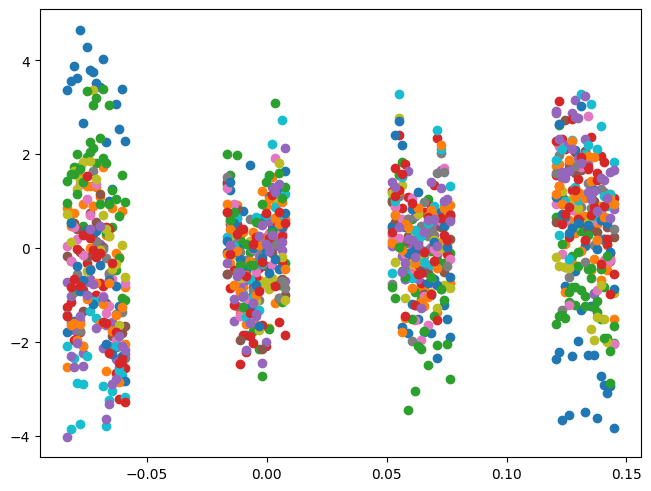

In [12]:
# Example showing how to load and read a rainbow file:
rainbow = read_rainbow(f"../data/{visit}_model_residuals.rainbow.npy")
residuals = rainbow.flux # (data-model)/err
wavelengths = rainbow.wavelength # micron
times = rainbow.time # time from T0 (days)
for i in range(len(wavelengths)):
    plt.scatter(times,residuals[i,:])

In [13]:
lc, contam, X, Y, _ = active_star.transit_model(**planet_parameters)

NameError: name 'active_star' is not defined

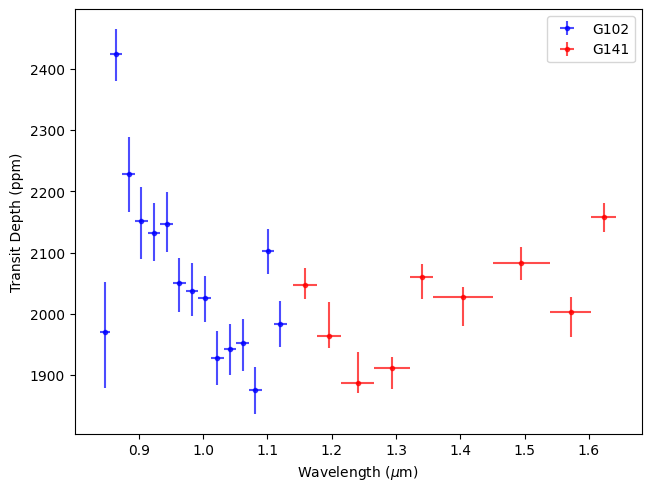

In [69]:
S22_radii = jnp.array([0.044379, 0.049249, 0.047204, 0.046387,
             0.046175, 0.046327, 0.045282, 0.045136, 
             0.045010, 0.043914, 0.044072, 0.044176, 
             0.043309, 0.045850, 0.044528])
S22_uncertainties = jnp.array([[0.0010221,0.0004613,0.0006498,0.0006619,
            0.0004989,0.0004914,0.0005233,0.0004510,
            0.0004416,0.0005135,0.0004808,0.0005125,
            0.0004644,0.0004059,0.0004192],
           [0.000935,0.000414,0.000645,0.000606,
            0.000535,0.000563,0.000451,0.000516,
            0.000400,0.000500,0.000473,0.000460,
            0.000432,0.000405,0.000421]])

F21_radii = jnp.array([0.045253, 0.044319, 0.043447, 0.043724, 0.045396, 0.045033, 0.045643, 0.044753, 0.046455])
F21_uncertainties = jnp.array([[0.0002565,0.0002283,0.0002044,0.0003992,0.0003996,0.0005269,0.0003132,0.00045,0.0002595],
           [0.000304,0.00063,0.000570,0.000200,0.000226,0.000170,0.000290,0.00028,0.000254]])

wavelength_bins = S22_bin_edges
S22wavelengths = (wavelength_bins[1:]-wavelength_bins[:-1])/2 + wavelength_bins[:-1]
wavelength_bins = F21_bin_edges
F21wavelengths = (wavelength_bins[1:]-wavelength_bins[:-1])/2 + wavelength_bins[:-1]

plt.errorbar(S22wavelengths, S22_radii**2*1e6, yerr=2*S22_uncertainties*S22_radii*1e6, xerr=S22wavelengths-S22_bin_edges[:-1],
             fmt='o',color='b',alpha=0.7,ms=3,label='G102')
plt.errorbar(F21wavelengths, F21_radii**2*1e6, yerr=2*F21_uncertainties*F21_radii*1e6, xerr=F21wavelengths-F21_bin_edges[:-1],
             fmt='o',color='r',alpha=0.7,ms=3,label='G141')

plt.ylabel('Transit Depth (ppm)')
plt.xlabel(r'Wavelength ($\mu$m)')
plt.legend()

In [83]:
S22_radii = jnp.array([0.044379, 0.049249, 0.047204, 0.046387,
             0.046175, 0.046327, 0.045282, 0.045136, 
             0.045010, 0.043914, 0.044072, 0.044176, 
             0.043309, 0.045850, 0.044528])
S22_uncertainties = jnp.array([[0.0010221,0.0004613,0.0006498,0.0006619,
            0.0004989,0.0004914,0.0005233,0.0004510,
            0.0004416,0.0005135,0.0004808,0.0005125,
            0.0004644,0.0004059,0.0004192],
           [0.000935,0.000414,0.000645,0.000606,
            0.000535,0.000563,0.000451,0.000516,
            0.000400,0.000500,0.000473,0.000460,
            0.000432,0.000405,0.000421]])

F21_radii = jnp.array([0.045253, 0.044319, 0.043447, 0.043724, 0.045396, 0.045033, 0.045643, 0.044753, 0.046455])
F21_uncertainties = jnp.array([[0.0002565,0.0002283,0.0002044,0.0003992,0.0003996,0.0005269,0.0003132,0.00045,0.0002595],
           [0.000304,0.00063,0.000570,0.000200,0.000226,0.000170,0.000290,0.00028,0.000254]])

wavelength_bins = S22_bin_edges
S22wavelengths = (wavelength_bins[1:]-wavelength_bins[:-1])/2 + wavelength_bins[:-1]
wavelength_bins = F21_bin_edges
F21wavelengths = (wavelength_bins[1:]-wavelength_bins[:-1])/2 + wavelength_bins[:-1]

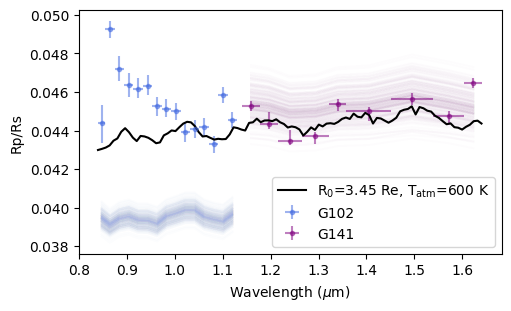

In [120]:
fig, axs = plt.subplots(1,1,figsize=(5,3),sharex=True)
axs.errorbar(S22wavelengths, S22_radii, yerr=S22_uncertainties, xerr=S22wavelengths-S22_bin_edges[:-1],
             fmt='o',color='royalblue',alpha=0.5,ms=3,label='G102')
axs.errorbar(F21wavelengths, F21_radii, yerr=F21_uncertainties, xerr=F21wavelengths-F21_bin_edges[:-1],
             fmt='o',color='purple',alpha=0.5,ms=3,label='G141')

P_ref = 0.1
power = 0.05
Mp = (12 * u.M_earth).cgs.value
pressures = np.logspace(-6, 1, 100)  # [bar]
temperatures = 600 * (pressures / P_ref) ** power  # [K]
molecules = ['H2O', 'CH4','CO2','CO','NH3']

wavelengths = S22wavelengths.value
binned_opacities = []
for mol in molecules:
    op = Opacity.load_species_from_name(mol)
    binned_opacities.append(
        op.get_binned_interpolator(wavelengths, temperatures, pressures) )
for this_R,this_T in zip(np.random.normal(3.17,0.02,200),np.random.normal(640,40,200)):
    model_rprs = dWS13_transmission_model(R_0 = (this_R * u.R_earth).cgs.value,
                                          T_ref = (this_T * u.K).value,
                                          P_ref = P_ref,
                                          power = power,Mp=Mp)
    axs.plot(wavelengths,model_rprs,alpha=0.01,color='royalblue')

wavelengths = F21wavelengths.value
binned_opacities = []
for mol in molecules:
    op = Opacity.load_species_from_name(mol)
    binned_opacities.append(
        op.get_binned_interpolator(wavelengths, temperatures, pressures) )
for this_R,this_T in zip(np.random.normal(3.56,0.03,200),np.random.normal(600,80,200)):
    model_rprs = dWS13_transmission_model(R_0 = (this_R * u.R_earth).cgs.value,
                                          T_ref = (this_T * u.K).value,
                                          P_ref = P_ref,
                                          power = power,Mp=Mp)
    axs.plot(wavelengths,model_rprs,alpha=0.01,color='purple')
    
wavelengths=np.linspace(0.84,1.64,100)
binned_opacities = []
for mol in molecules:
    op = Opacity.load_species_from_name(mol)
    binned_opacities.append(
        op.get_binned_interpolator(wavelengths, temperatures, pressures) )
model_rprs = dWS13_transmission_model(R_0 = (3.45 * u.R_earth).cgs.value,
                                      T_ref = (600* u.K).value,
                                      P_ref = 0.1,
                                      power=0.05,Mp=(10 * u.M_earth).cgs.value
)
axs.plot(wavelengths,model_rprs,alpha=1,color='k',label=r'R$_0$=3.45 Re, T$_{\rm atm}$=600 K')

axs.set_ylabel('Rp/Rs')
axs.set_xlabel(r'Wavelength ($\mu$m)')
axs.legend()
plt.savefig(f'Transmissionspectrum.png',dpi=300)

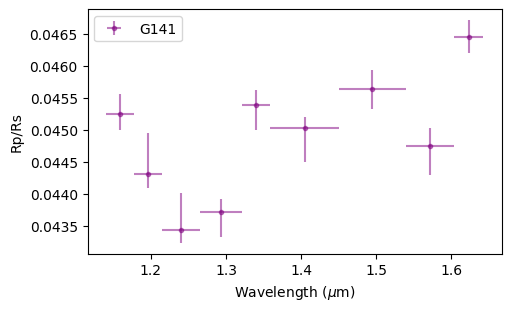

In [125]:
fig, axs = plt.subplots(1,1,figsize=(5,3),sharex=True)
# axs.errorbar(S22wavelengths, S22_radii, yerr=S22_uncertainties, xerr=S22wavelengths-S22_bin_edges[:-1],
#              fmt='o',color='royalblue',alpha=0.5,ms=3,label='G102')
axs.errorbar(F21wavelengths, F21_radii, yerr=F21_uncertainties, xerr=F21wavelengths-F21_bin_edges[:-1],
             fmt='o',color='purple',alpha=0.5,ms=3,label='G141')

axs.set_ylabel('Rp/Rs')
axs.set_xlabel(r'Wavelength ($\mu$m)')
axs.legend()
plt.savefig(f'S22_retrieval_Transmissionspectrum.png',dpi=300)

/var/folders/vq/zxq380ws52q37mjjtbt9c7rh0000gp/T/ipykernel_45905/327945272.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs.legend()


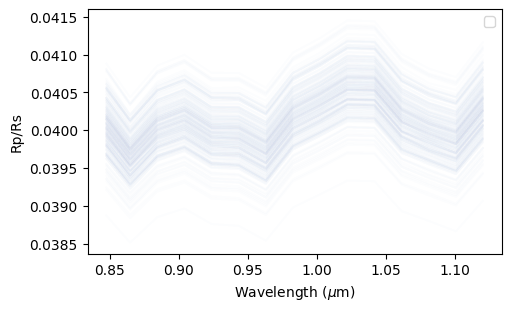

In [123]:
P_ref = 0.1
power = 0.05
Mp = (10 * u.M_earth).cgs.value
pressures = np.logspace(-6, 1, 100)  # [bar]
temperatures = 600 * (pressures / P_ref) ** power  # [K]
molecules = ['H2O', 'CH4','CO2','CO','NH3']

wavelengths = S22wavelengths.value
binned_opacities = []
for mol in molecules:
    op = Opacity.load_species_from_name(mol)
    binned_opacities.append(
        op.get_binned_interpolator(wavelengths, temperatures, pressures) )
for this_R,this_T in zip(np.random.normal(3.17,0.02,200),np.random.normal(640,40,200)):
    model_rprs = dWS13_transmission_model(R_0 = (this_R * u.R_earth).cgs.value,
                                          T_ref = (this_T * u.K).value,
                                          P_ref = P_ref,
                                          power = power,Mp=Mp)
    axs.plot(wavelengths,model_rprs,alpha=0.01,color='royalblue')

# wavelengths = F21wavelengths.value
# binned_opacities = []
# for mol in molecules:
#     op = Opacity.load_species_from_name(mol)
#     binned_opacities.append(
#         op.get_binned_interpolator(wavelengths, temperatures, pressures) )
# for this_R,this_T in zip(np.random.normal(3.56,0.03,200),np.random.normal(600,80,200)):
#     model_rprs = dWS13_transmission_model(R_0 = (3.56 * u.R_earth).cgs.value,
#                                           T_ref = (this_T * u.K).value,
#                                           P_ref = P_ref,
#                                           power = power,Mp=Mp)
#     axs.plot(wavelengths,model_rprs,alpha=0.02,color='k')

axs.set_ylabel('Rp/Rs')
axs.set_xlabel(r'Wavelength ($\mu$m)')
axs.legend()
plt.savefig(f'S22_retrieval_Transmissionspectrum.png',dpi=300)